In [1]:
pip install pandas numpy matplotlib seaborn sqlalchemy openpyxl

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [4]:
df = pd.read_csv('supply_chain_data.csv')

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nFirst 5 rows:")
df.head()

Shape: (100, 24)

Columns: ['Product type', 'SKU', 'Price', 'Availability', 'Number of products sold', 'Revenue generated', 'Customer demographics', 'Stock levels', 'Lead times', 'Order quantities', 'Shipping times', 'Shipping carriers', 'Shipping costs', 'Supplier name', 'Location', 'Lead time', 'Production volumes', 'Manufacturing lead time', 'Manufacturing costs', 'Inspection results', 'Defect rates', 'Transportation modes', 'Routes', 'Costs']

Data Types:
Product type                object
SKU                         object
Price                      float64
Availability                 int64
Number of products sold      int64
Revenue generated          float64
Customer demographics       object
Stock levels                 int64
Lead times                   int64
Order quantities             int64
Shipping times               int64
Shipping carriers           object
Shipping costs             float64
Supplier name               object
Location                    object
Lead time  

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632


In [5]:
print("=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Basic Stats ===")
print(df.describe())

print("\n=== Unique values per column ===")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

=== Missing Values ===
Product type               0
SKU                        0
Price                      0
Availability               0
Number of products sold    0
Revenue generated          0
Customer demographics      0
Stock levels               0
Lead times                 0
Order quantities           0
Shipping times             0
Shipping carriers          0
Shipping costs             0
Supplier name              0
Location                   0
Lead time                  0
Production volumes         0
Manufacturing lead time    0
Manufacturing costs        0
Inspection results         0
Defect rates               0
Transportation modes       0
Routes                     0
Costs                      0
dtype: int64

=== Basic Stats ===
            Price  Availability  Number of products sold  Revenue generated  \
count  100.000000    100.000000               100.000000         100.000000   
mean    49.462461     48.400000               460.990000        5776.048187   
std     31

In [6]:
df_clean = df.copy()

# Rename columns for easier use
df_clean.columns = [col.strip().lower().replace(' ', '_') for col in df_clean.columns]

# Drop duplicates
df_clean = df_clean.drop_duplicates()

# Fill missing numeric values with median
num_cols = df_clean.select_dtypes(include='number').columns
df_clean[num_cols] = df_clean[num_cols].fillna(df_clean[num_cols].median())

# Fill missing categorical values with 'Unknown'
cat_cols = df_clean.select_dtypes(include='object').columns
df_clean[cat_cols] = df_clean[cat_cols].fillna('Unknown')

print(f"Clean shape: {df_clean.shape}")
print(f"\nCleaned columns: {df_clean.columns.tolist()}")
print(f"\nMissing values after cleaning:\n{df_clean.isnull().sum().sum()} total")
df_clean.head()

Clean shape: (100, 24)

Cleaned columns: ['product_type', 'sku', 'price', 'availability', 'number_of_products_sold', 'revenue_generated', 'customer_demographics', 'stock_levels', 'lead_times', 'order_quantities', 'shipping_times', 'shipping_carriers', 'shipping_costs', 'supplier_name', 'location', 'lead_time', 'production_volumes', 'manufacturing_lead_time', 'manufacturing_costs', 'inspection_results', 'defect_rates', 'transportation_modes', 'routes', 'costs']

Missing values after cleaning:
0 total


,product_type,sku,price,availability,number_of_products_sold,revenue_generated,customer_demographics,stock_levels,lead_times,order_quantities,...,location,lead_time,production_volumes,manufacturing_lead_time,manufacturing_costs,inspection_results,defect_rates,transportation_modes,routes,costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632


In [7]:
# Days of Supply — how many days current stock will last at current sales rate
df_clean['daily_demand'] = df_clean['number_of_products_sold'] / 30
df_clean['days_of_supply'] = np.where(
    df_clean['daily_demand'] > 0,
    df_clean['stock_levels'] / df_clean['daily_demand'],
    999  # no demand = no stockout risk
)

# Stockout Risk Flag — if days of supply < lead time, we'll run out before restock
df_clean['stockout_risk'] = np.where(df_clean['days_of_supply'] < df_clean['lead_times'], 'At Risk', 'Safe')

# Overstock Flag — if days of supply > 3x lead time, too much inventory
df_clean['overstock'] = np.where(df_clean['days_of_supply'] > df_clean['lead_times'] * 3, 'Overstocked', 'Normal')

# Profit Margin
df_clean['profit_margin'] = ((df_clean['revenue_generated'] - df_clean['manufacturing_costs']) 
                              / df_clean['revenue_generated'] * 100).round(2)

# Reorder Quantity — simple formula: avg daily demand * lead time * 1.5 safety factor
df_clean['reorder_qty'] = (df_clean['daily_demand'] * df_clean['lead_times'] * 1.5).round(0).astype(int)

print("=== Stockout Risk Summary ===")
print(df_clean['stockout_risk'].value_counts())

print("\n=== Overstock Summary ===")
print(df_clean['overstock'].value_counts())

print("\n=== New columns added ===")
print(['daily_demand', 'days_of_supply', 'stockout_risk', 'overstock', 'profit_margin', 'reorder_qty'])

=== Stockout Risk Summary ===
At Risk    81
Safe       19
Name: stockout_risk, dtype: int64

=== Overstock Summary ===
Normal         93
Overstocked     7
Name: overstock, dtype: int64

=== New columns added ===
['daily_demand', 'days_of_supply', 'stockout_risk', 'overstock', 'profit_margin', 'reorder_qty']


In [8]:
# Load data into SQLite
engine = create_engine('sqlite:///supply_chain.db')
df_clean.to_sql('supply_chain', engine, if_exists='replace', index=False)
print("✅ Data loaded into SQLite")

# --- Query 1: Revenue & profit by product type ---
q1 = pd.read_sql("""
    SELECT product_type,
           COUNT(*) as total_skus,
           ROUND(SUM(revenue_generated), 2) as total_revenue,
           ROUND(AVG(profit_margin), 2) as avg_profit_margin
    FROM supply_chain
    GROUP BY product_type
    ORDER BY total_revenue DESC
""", engine)
print("\n=== Revenue by Product Type ===")
print(q1)

# --- Query 2: Stockout risk by supplier ---
q2 = pd.read_sql("""
    SELECT supplier_name,
           COUNT(*) as total_products,
           SUM(CASE WHEN stockout_risk = 'At Risk' THEN 1 ELSE 0 END) as at_risk_count,
           ROUND(AVG(days_of_supply), 1) as avg_days_of_supply
    FROM supply_chain
    GROUP BY supplier_name
    ORDER BY at_risk_count DESC
""", engine)
print("\n=== Stockout Risk by Supplier ===")
print(q2)

# --- Query 3: Top 10 SKUs by stockout risk ---
q3 = pd.read_sql("""
    SELECT sku, product_type, stock_levels, daily_demand,
           ROUND(days_of_supply, 1) as days_of_supply,
           lead_times, reorder_qty
    FROM supply_chain
    WHERE stockout_risk = 'At Risk'
    ORDER BY days_of_supply ASC
    LIMIT 10
""", engine)
print("\n=== Top 10 SKUs at Stockout Risk ===")
print(q3)

# --- Query 4: Shipping cost by carrier ---
q4 = pd.read_sql("""
    SELECT shipping_carriers,
           COUNT(*) as shipments,
           ROUND(AVG(shipping_costs), 2) as avg_shipping_cost,
           ROUND(AVG(shipping_times), 1) as avg_shipping_days
    FROM supply_chain
    GROUP BY shipping_carriers
    ORDER BY avg_shipping_cost DESC
""", engine)
print("\n=== Shipping Cost by Carrier ===")
print(q4)

✅ Data loaded into SQLite

=== Revenue by Product Type ===
  product_type  total_skus  total_revenue  avg_profit_margin
0     skincare          40      241628.16              98.66
1     haircare          34      174455.39              98.57
2    cosmetics          26      161521.27              99.16

=== Stockout Risk by Supplier ===
  supplier_name  total_products  at_risk_count  avg_days_of_supply
0    Supplier 1              27             25                 5.0
1    Supplier 2              22             17                 9.8
2    Supplier 4              18             14                 7.4
3    Supplier 3              15             14                 3.1
4    Supplier 5              18             11                 6.6

=== Top 10 SKUs at Stockout Risk ===
     sku product_type  stock_levels  daily_demand  days_of_supply  lead_times  \
0  SKU34     skincare             1     20.066667             0.0          26   
1  SKU68     haircare             0      5.433333           

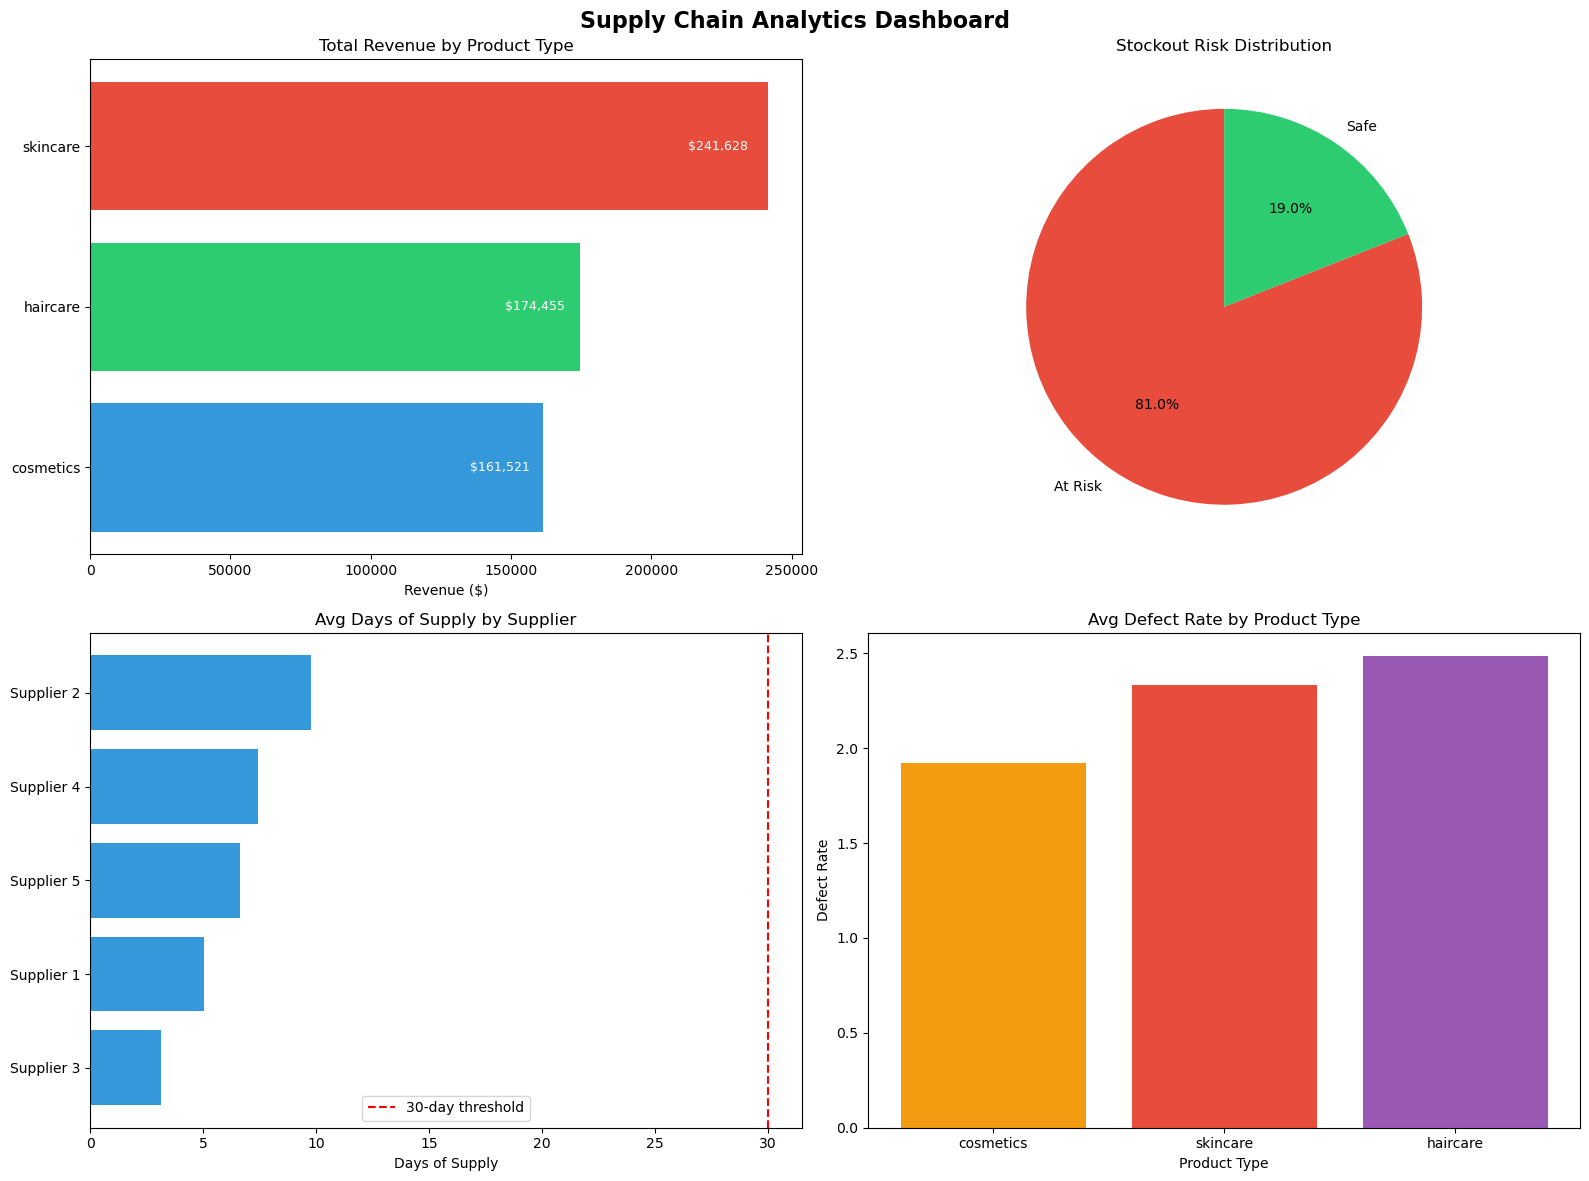

✅ Visualization saved!


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Supply Chain Analytics Dashboard', fontsize=16, fontweight='bold')

# 1 — Revenue by Product Type
ax1 = axes[0, 0]
rev_data = df_clean.groupby('product_type')['revenue_generated'].sum().sort_values()
colors = ['#3498db', '#2ecc71', '#e74c3c']
ax1.barh(rev_data.index, rev_data.values, color=colors)
ax1.set_title('Total Revenue by Product Type')
ax1.set_xlabel('Revenue ($)')
for bar, val in zip(ax1.patches, rev_data.values):
    ax1.text(bar.get_width()*0.97, bar.get_y()+bar.get_height()/2,
             f'${val:,.0f}', va='center', ha='right', color='white', fontsize=9)

# 2 — Stockout Risk Distribution
ax2 = axes[0, 1]
risk_counts = df_clean['stockout_risk'].value_counts()
ax2.pie(risk_counts, labels=risk_counts.index, autopct='%1.1f%%',
        colors=['#e74c3c', '#2ecc71'], startangle=90)
ax2.set_title('Stockout Risk Distribution')

# 3 — Avg Days of Supply by Supplier
ax3 = axes[1, 0]
sup_data = df_clean.groupby('supplier_name')['days_of_supply'].mean().sort_values()
ax3.barh(sup_data.index, sup_data.values, color='#3498db')
ax3.axvline(x=30, color='red', linestyle='--', label='30-day threshold')
ax3.set_title('Avg Days of Supply by Supplier')
ax3.set_xlabel('Days of Supply')
ax3.legend()

# 4 — Defect Rate by Product Type
ax4 = axes[1, 1]
defect_data = df_clean.groupby('product_type')['defect_rates'].mean().sort_values()
ax4.bar(defect_data.index, defect_data.values, color=['#f39c12', '#e74c3c', '#9b59b6'])
ax4.set_title('Avg Defect Rate by Product Type')
ax4.set_ylabel('Defect Rate')
ax4.set_xlabel('Product Type')

plt.tight_layout()
plt.savefig(r'C:\Users\Yash\Downloads\YASH\supply_chain_analytics\supply_chain_viz.png', dpi=150)
plt.show()
print("✅ Visualization saved!")

In [10]:
export_path = r'C:\Users\Yash\Downloads\YASH\supply_chain_analytics\supply_chain_clean.csv'
df_clean.to_csv(export_path, index=False)
print(f"✅ Exported: supply_chain_clean.csv")
print(f"Columns: {df_clean.columns.tolist()}")
print(f"Shape: {df_clean.shape}")

✅ Exported: supply_chain_clean.csv
Columns: ['product_type', 'sku', 'price', 'availability', 'number_of_products_sold', 'revenue_generated', 'customer_demographics', 'stock_levels', 'lead_times', 'order_quantities', 'shipping_times', 'shipping_carriers', 'shipping_costs', 'supplier_name', 'location', 'lead_time', 'production_volumes', 'manufacturing_lead_time', 'manufacturing_costs', 'inspection_results', 'defect_rates', 'transportation_modes', 'routes', 'costs', 'daily_demand', 'days_of_supply', 'stockout_risk', 'overstock', 'profit_margin', 'reorder_qty']
Shape: (100, 30)
